# Carnet de calcul — Design

## Description

*(à compléter)*

## 0. Variables

Convention : tout en **cm** sauf indication contraire. **x** vers la droite, **y** = profondeur sous le sol (positive vers le bas).


### 0.1 Bibliothèques et fonctions d'affichage

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math, Markdown

def afficher(description, nom, valeur, unite=""):
    """Imprime : description (NOM_DANS_LE_CODE) = valeur unité"""
    if valeur is None:
        texte = "None  -> calculé par le carnet"
    else:
        texte = f"{valeur:g} {unite}".strip()
    print(f"{description} ({nom}) = {texte}")

def fr(x, d=2):
    """Nombre avec d décimales et virgule décimale (notation LaTeX)."""
    return f"{x:.{d}f}".replace(".", "{,}")

def T(modele, **valeurs):
    """Remplace @nom@ par la valeur dans un modèle LaTeX."""
    for k, v in valeurs.items():
        modele = modele.replace(f"@{k}@", str(v))
    return modele

def eq(latex):
    """Affiche une équation en mode display."""
    display(Math(latex))

def note(texte_markdown):
    """Affiche un texte (Markdown)."""
    display(Markdown(texte_markdown))


### 0.2 Débit de conception

In [2]:
Q_CONCEPTION_M3_J = 1.26                             # débit de conception (m3/jour)
Q_CONCEPTION_L_J = Q_CONCEPTION_M3_J * 1000          # débit de conception (L/jour)
Q_CONCEPTION_LS = Q_CONCEPTION_L_J / 86400            # débit de conception (L/s)

afficher("Débit de conception", "Q_CONCEPTION_M3_J", Q_CONCEPTION_M3_J, "m3/jour")
afficher("Débit de conception", "Q_CONCEPTION_L_J", Q_CONCEPTION_L_J, "L/jour")
afficher("Débit de conception", "Q_CONCEPTION_LS", Q_CONCEPTION_LS, "L/s")

Débit de conception (Q_CONCEPTION_M3_J) = 1.26 m3/jour
Débit de conception (Q_CONCEPTION_L_J) = 1260 L/jour
Débit de conception (Q_CONCEPTION_LS) = 0.0145833 L/s


### 0.3 Profil de consommation horaire

**Hypothèse.** Profil ajusté à la main sur la forme d'un graphique fourni (pointe du matin 7h-9h, pointe du soir 18h-21h), plutôt que sur le profil Perlman et Mills utilisé précédemment. Source à documenter.

Debit horaire maximal (heure de pointe) (Q_MAX_L_H) = 104.324 L/h
Debit horaire maximal (Q_MAX_L_S) = 0.0289788 L/s
Debit horaire moyen (Q_MOY_L_H) = 52.5 L/h


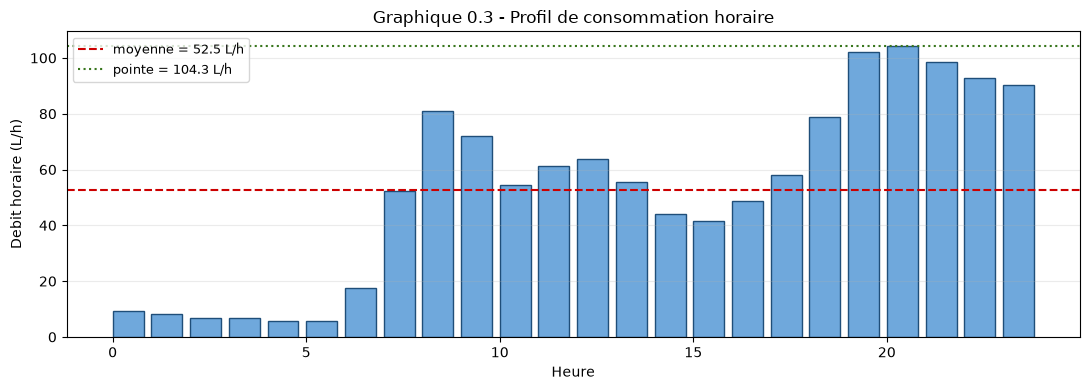

In [3]:
VALEURS_RELATIVES_HORAIRE = [8, 7, 6, 6, 5, 5, 15, 45, 70, 62, 47, 53, 55, 48, 38, 36, 42, 50, 68, 88, 90, 85, 80, 78]
                        # lecture approximative du graphique fourni (unites arbitraires, forme de la courbe seulement)
FRACTION_HORAIRE_PCT = [v / sum(VALEURS_RELATIVES_HORAIRE) * 100 for v in VALEURS_RELATIVES_HORAIRE]   # normalise a 100%

Q_HORAIRE_L_H = [f / 100 * Q_CONCEPTION_L_J for f in FRACTION_HORAIRE_PCT]   # debit horaire (L/h), deja avec securite (0.2)
Q_HORAIRE_M3S = [q / 1000 / 3600 for q in Q_HORAIRE_L_H]                              # debit horaire (m3/s)
Q_MAX_L_H = max(Q_HORAIRE_L_H)
Q_MAX_L_S = Q_MAX_L_H / 3600
Q_MOY_L_H = Q_CONCEPTION_L_J / 24

afficher("Debit horaire maximal (heure de pointe)", "Q_MAX_L_H", Q_MAX_L_H, "L/h")
afficher("Debit horaire maximal", "Q_MAX_L_S", Q_MAX_L_S, "L/s")
afficher("Debit horaire moyen", "Q_MOY_L_H", Q_MOY_L_H, "L/h")

fig, ax = plt.subplots(figsize=(11, 4))
heures = list(range(24))
ax.bar(heures, Q_HORAIRE_L_H, width=0.8, align="edge", color="#6fa8dc", edgecolor="#1f4e79")
ax.axhline(Q_MOY_L_H, color="#cc0000", ls="--", label=f"moyenne = {Q_MOY_L_H:.1f} L/h")
ax.axhline(Q_MAX_L_H, color="#38761d", ls=":", label=f"pointe = {Q_MAX_L_H:.1f} L/h")
ax.set_xlabel("Heure"); ax.set_ylabel("Debit horaire (L/h)"); ax.legend(fontsize=9); ax.grid(alpha=0.25, axis="y")
ax.set_title("Graphique 0.3 - Profil de consommation horaire")
plt.tight_layout(); plt.show()

### 0.4 Chauffage de l'eau

In [4]:
T_ENTREE_C = 4.0         # température de l'eau à l'entrée, la plus froide dans le sol (°C)
T_SORTIE_MIN_C = 20.0    # température de sortie minimale acceptable (utilisée en 1.1-1.3, cas de reference) (°C)
T_SORTIE_MAX_C = 37.0    # température de sortie maximale acceptable (°C)
CONSIGNE_MIN_REQUISE_C = 15.0     # consigne minimale requise (important : doit toujours etre atteinte) (°C)
CONSIGNE_VISEE_HAUTE_C = 36.0     # consigne haute visee par l'usagere, a valider (le maximum reellement atteignable est calcule en 1.4) (°C)
CP_EAU = 4186.0          # capacité thermique massique de l'eau, ~constante sur 4-37°C (J/(kg·K)) (1)
RHO_EAU = 1000.0         # masse volumique de l'eau (kg/m3)

afficher("Température d'entrée", "T_ENTREE_C", T_ENTREE_C, "°C")
afficher("Température de sortie minimale acceptable", "T_SORTIE_MIN_C", T_SORTIE_MIN_C, "°C")
afficher("Température de sortie maximale acceptable", "T_SORTIE_MAX_C", T_SORTIE_MAX_C, "°C")
afficher("Consigne minimale requise (important)", "CONSIGNE_MIN_REQUISE_C", CONSIGNE_MIN_REQUISE_C, "°C")
afficher("Consigne haute visee (a valider)", "CONSIGNE_VISEE_HAUTE_C", CONSIGNE_VISEE_HAUTE_C, "°C")
afficher("Capacité thermique massique de l'eau", "CP_EAU", CP_EAU, "J/(kg·K)")
afficher("Masse volumique de l'eau", "RHO_EAU", RHO_EAU, "kg/m3")

Température d'entrée (T_ENTREE_C) = 4 °C
Température de sortie minimale acceptable (T_SORTIE_MIN_C) = 20 °C
Température de sortie maximale acceptable (T_SORTIE_MAX_C) = 37 °C
Consigne minimale requise (important) (CONSIGNE_MIN_REQUISE_C) = 15 °C
Consigne haute visee (a valider) (CONSIGNE_VISEE_HAUTE_C) = 36 °C
Capacité thermique massique de l'eau (CP_EAU) = 4186 J/(kg·K)
Masse volumique de l'eau (RHO_EAU) = 1000 kg/m3


### 0.5 Électricité

**Sources**

(1) Hydro-Québec, *Tarif D — résidentiel*, taux applicable à l'énergie consommée (2e tranche, tarif 2026). <https://www.hydroquebec.com/residentiel/espace-clients/tarifs/tarif-d.html>

In [5]:
PRIX_ELECTRICITE_CENT_KWH = 7.065                          # prix de l'énergie électrique (¢/kWh) (1)
PRIX_ELECTRICITE_CAD_KWH = PRIX_ELECTRICITE_CENT_KWH / 100   # prix de l'énergie électrique ($/kWh)

afficher("Prix de l'électricité", "PRIX_ELECTRICITE_CENT_KWH", PRIX_ELECTRICITE_CENT_KWH, "¢/kWh")
afficher("Prix de l'électricité", "PRIX_ELECTRICITE_CAD_KWH", PRIX_ELECTRICITE_CAD_KWH, "$/kWh")

Prix de l'électricité (PRIX_ELECTRICITE_CENT_KWH) = 7.065 ¢/kWh
Prix de l'électricité (PRIX_ELECTRICITE_CAD_KWH) = 0.07065 $/kWh


### 0.6 Plastique HDPE (prix préliminaire)

**Hypothèse.** Prix préliminaire fourni par le fabricant pour une feuille de HDPE de 4 pi x 8 pi, épaisseur 0,6 cm — à remplacer par un prix ferme une fois le fournisseur confirmé.\n\n**Sources**\n\n(2) Valeur typique de conductivité thermique du HDPE (0,45-0,52 W/(m·K)), plastiques techniques, valeur générique — à remplacer par la fiche du fournisseur retenu.

In [6]:
LARGEUR_FEUILLE_HDPE_CM = 121.92     # largeur d'une feuille de HDPE (cm) -- feuille source 4 pi x 8 pi
LONGUEUR_FEUILLE_HDPE_CM = 243.84    # longueur d'une feuille de HDPE (cm)
EPAISSEUR_FEUILLE_HDPE_CM = 0.6        # épaisseur de la feuille de HDPE (cm)
PRIX_FEUILLE_HDPE_CAD = 110.0          # prix d'une feuille de HDPE (prix préliminaire) ($)
K_HDPE = 0.48                          # conductivité thermique du HDPE (W/(m·K)) (2)
TEMP_EXTERIEURE_C = 4.0                # température du sol/de l'air à l'extérieur de la cuve (°C) — même température que l'entrée

AIRE_FEUILLE_HDPE_M2 = (LARGEUR_FEUILLE_HDPE_CM / 100) * (LONGUEUR_FEUILLE_HDPE_CM / 100)   # aire d'une feuille (m2)
PRIX_HDPE_CAD_M2 = PRIX_FEUILLE_HDPE_CAD / AIRE_FEUILLE_HDPE_M2              # prix unitaire du HDPE ($/m2)
EPAISSEUR_FEUILLE_HDPE_M = EPAISSEUR_FEUILLE_HDPE_CM / 100                   # épaisseur (m), pour le calcul de pertes

afficher("Largeur d'une feuille de HDPE", "LARGEUR_FEUILLE_HDPE_CM", LARGEUR_FEUILLE_HDPE_CM, "cm")
afficher("Longueur d'une feuille de HDPE", "LONGUEUR_FEUILLE_HDPE_CM", LONGUEUR_FEUILLE_HDPE_CM, "cm")
afficher("Épaisseur de la feuille de HDPE", "EPAISSEUR_FEUILLE_HDPE_CM", EPAISSEUR_FEUILLE_HDPE_CM, "cm")
afficher("Prix d'une feuille de HDPE", "PRIX_FEUILLE_HDPE_CAD", PRIX_FEUILLE_HDPE_CAD, "$")
afficher("Aire d'une feuille de HDPE", "AIRE_FEUILLE_HDPE_M2", AIRE_FEUILLE_HDPE_M2, "m2")
afficher("Prix unitaire du HDPE", "PRIX_HDPE_CAD_M2", PRIX_HDPE_CAD_M2, "$/m2")
afficher("Conductivité thermique du HDPE", "K_HDPE", K_HDPE, "W/(m·K)")
afficher("Température extérieure (sol/air)", "TEMP_EXTERIEURE_C", TEMP_EXTERIEURE_C, "°C")

Largeur d'une feuille de HDPE (LARGEUR_FEUILLE_HDPE_CM) = 121.92 cm
Longueur d'une feuille de HDPE (LONGUEUR_FEUILLE_HDPE_CM) = 243.84 cm
Épaisseur de la feuille de HDPE (EPAISSEUR_FEUILLE_HDPE_CM) = 0.6 cm
Prix d'une feuille de HDPE (PRIX_FEUILLE_HDPE_CAD) = 110 $
Aire d'une feuille de HDPE (AIRE_FEUILLE_HDPE_M2) = 2.9729 m2
Prix unitaire du HDPE (PRIX_HDPE_CAD_M2) = 37.0009 $/m2
Conductivité thermique du HDPE (K_HDPE) = 0.48 W/(m·K)
Température extérieure (sol/air) (TEMP_EXTERIEURE_C) = 4 °C


### 0.7 Catalogue des éléments chauffants (McMaster-Carr) et régulateur

Catalogue des éléments chauffants à immersion à visser, pour l'eau, 120 V CA monophasé, sans contrôle de température intégré (contrôle par thermostat externe à sonde). Deux gammes : standard (corps laiton) et compacte (corps inox 316/Incoloy). Seules les versions à un seul élément sont retenues.

**Sources**

(1) McMaster-Carr, *Screw-Plug Immersion Heating Elements for Water* et *Compact Screw-Plug Immersion Heating Elements for Water*, 120V AC, monophasé, sans contrôle de température. <https://www.mcmaster.com/screw-plug-immersion-heaters/>

(2) Inkbird, *ITC-1000, contrôleur de température à sonde*, plage -50°C à 99°C, relais 10A/250V. ~27 \\$ CAD (20 \\$ US). <https://www.inkbird.com/products/temperature-controller-itc-1000>

In [7]:
# (puissance_W, longueur_po, filetage, no_piece, prix_cad)
CATALOGUE_STANDARD = [
    (500,  6.375, '1-1/8" NPT', '3656K103', 203.95),
    (750,  6.375, '1-1/8" NPT', '3656K231', 199.38),
    (1000, 6.25,  '1-3/8" NPT', '3656K11',  150.05),
    (1000, 6.375, '1-1/8" NPT', '3656K104', 200.47),
    (1500, 7.25,  '1-3/8" NPT', '3656K12',  180.60),
    (1500, 9.25,  '1-1/8" NPT', '3656K105', 251.72),
    (2000, 9.25,  '1-3/8" NPT', '3656K13',  192.80),
    (3000, 8.0,   '2" NPT',     '3656K155', None),   # monophase 240V, prix non affiche publiquement par McMaster-Carr, a confirmer (3)
]
CATALOGUE_COMPACT = [
    (55,   1.625,  '1/8" NPT', '4668T51',  127.49),
    (75,   1.5625, '1/4" NPT', '4668T53',  134.23),
    (100,  1.625,  '1/8" NPT', '4668T101', 125.95),
    (120,  1.5625, '1/4" NPT', '4668T103', 132.56),
    (170,  4.625,  '1/8" NPT', '4668T52',  146.39),
    (200,  2.4375, '1/2" NPT', '4668T105', 191.43),
    (250,  4.5625, '1/4" NPT', '4668T54',  152.88),
    (300,  4.625,  '1/8" NPT', '4668T102', 144.37),
    (325,  5.5625, '1/4" NPT', '4668T104', 151.30),
    (400,  2.4375, '1/2" NPT', '4668T106', 191.43),
    (405,  4.4375, '1/2" NPT', '4668T56',  204.05),
    (500,  4.875,  '3/4" NPT', '4654T11',  193.18),
    (700,  4.4375, '1/2" NPT', '4668T107', 202.24),
    (750,  4.875,  '3/4" NPT', '4654T12',  193.18),
    (800,  5.25,   '1" NPT',   '4668T1',   259.02),
    (1000, 4.875,  '3/4" NPT', '4654T13',  193.18),
    (1200, 7.75,   '1" NPT',   '4668T2',   282.15),
    (1750, 11.25,  '1" NPT',   '4668T3',   301.46),
]
CATALOGUE_COMPLET = [dict(gamme="Standard", puissance_W=p, longueur_po=l, filetage=t, piece=n, prix_element_cad=pr)
                      for p, l, t, n, pr in CATALOGUE_STANDARD] + \
                    [dict(gamme="Compacte", puissance_W=p, longueur_po=l, filetage=t, piece=n, prix_element_cad=pr)
                      for p, l, t, n, pr in CATALOGUE_COMPACT]

PRIX_REGULATEUR_CAD = 27.0        # Inkbird ITC-1000, controleur de temperature a sonde (2)
PUISSANCE_REGULATEUR_W = 2.0      # consommation de veille estimee du regulateur (electronique + relais), a confirmer (2)

ENERGIE_REGULATEUR_KWH_JOUR = PUISSANCE_REGULATEUR_W * 24 / 1000
COUT_REGULATEUR_ELEC_JOUR = ENERGIE_REGULATEUR_KWH_JOUR * PRIX_ELECTRICITE_CAD_KWH

afficher("Nombre d'elements au catalogue", "len(CATALOGUE_COMPLET)", len(CATALOGUE_COMPLET), "")
afficher("Prix du regulateur (Inkbird ITC-1000)", "PRIX_REGULATEUR_CAD", PRIX_REGULATEUR_CAD, "$")
afficher("Consommation de veille du regulateur", "PUISSANCE_REGULATEUR_W", PUISSANCE_REGULATEUR_W, "W")
afficher("Energie du regulateur", "ENERGIE_REGULATEUR_KWH_JOUR", ENERGIE_REGULATEUR_KWH_JOUR, "kWh/jour")
afficher("Cout electrique du regulateur", "COUT_REGULATEUR_ELEC_JOUR", COUT_REGULATEUR_ELEC_JOUR, "$/jour")

Nombre d'elements au catalogue (len(CATALOGUE_COMPLET)) = 26
Prix du regulateur (Inkbird ITC-1000) (PRIX_REGULATEUR_CAD) = 27 $
Consommation de veille du regulateur (PUISSANCE_REGULATEUR_W) = 2 W
Energie du regulateur (ENERGIE_REGULATEUR_KWH_JOUR) = 0.048 kWh/jour
Cout electrique du regulateur (COUT_REGULATEUR_ELEC_JOUR) = 0.0033912 $/jour


### 0.8 Isolant autour de la cuve (options retenues)

**Théorie.** Trois isolants rigides sont retenus (voir comparatif préliminaire) : XPS, EPS et polyiso — les trois avec fiche technique de fabricant et fournisseur québécois identifié. La conductivité thermique $k$ (W/(m·K)) de chacun est calculée à partir de sa résistance thermique par pouce $R_{po}$ (valeur de fiche technique, en h·pi²·°F/BTU par po) :

$$k = \dfrac{0{,}1442}{R_{po}}$$

**Hypothèse.** Prix ramenés à un prix unitaire $/pi²/po (comme pour le HDPE, 0.6), à partir du prix réel d'une feuille 4×8 pi à une épaisseur donnée. Pour l'EPS, aucun prix ferme n'a été trouvé pour un produit précis chez les fournisseurs consultés (ADEX, Isolofoam) : une estimation prudente est utilisée (prix générique inférieur au XPS, cohérent avec le marché), à confirmer par soumission.

**Sources**

(1) SOPREMA, *SOPRA-XPS 20* — R-5/po, fiche technique <http://files.soprema.ca/2019-04-09/FT_SOPRA-XPS_20.pdf5cacd433b1c6f2f4b6be80d274139c67a02f6b9707732.pdf>. Prix : Matériaux Audet, panneau 2 po x 4 pi x 8 pi, 54,39 \\$ (2026). <https://materiauxaudet.ca/produit/panneau-isolant-sopra-xps-20-2-x-4-x-8/>

(2) ADEX, *EPS-FLAT* — R-4,0/po (testé à 10°C), fiche technique de sécurité <https://www.adex.ca/wp-content/uploads/2016/09/fs-eps.pdf>. Prix : estimation (aucun prix ferme trouvé pour un produit précis) — à confirmer auprès d'ADEX, Isolofoam ou Legerlite (fabricants québécois).

(3) IKO, *EnerFoil* (polyisocyanurate, équivalent SOPRA-ISO de SOPREMA) — R-6/po (R-12 à 2 po). Prix : Matériaux Audet, panneau 2 po x 4 pi x 8 pi, 59,87 \\$ (2026). <https://materiauxaudet.ca/produit/panneau-isolant-de-polyisocyanurate-rigide-iko-enerfoil-4-x-8-x-2-unite/>

In [8]:
AIRE_FEUILLE_ISOLANT_M2 = (LARGEUR_FEUILLE_HDPE_CM / 100) * (LONGUEUR_FEUILLE_HDPE_CM / 100)   # feuille standard 4 pi x 8 pi, comme le HDPE

ISOLANTS = [
    dict(nom="XPS", piece="SOPREMA Sopra-XPS 20", R_po=5.0,
         epaisseurs_cm=[e * 2.54 for e in [1.0, 1.5, 2.0, 3.0, 4.0]],
         prix_feuille_2po_cad=54.39, epaisseur_prix_cm=2.0 * 2.54),
    dict(nom="EPS", piece="Isolofoam / ADEX Type 2 (estimation)", R_po=4.0,
         epaisseurs_cm=[e * 2.54 for e in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]],
         prix_feuille_2po_cad=32.00, epaisseur_prix_cm=2.0 * 2.54),   # estimation, a confirmer (2)
    dict(nom="Polyiso", piece="IKO EnerFoil", R_po=6.0,
         epaisseurs_cm=[e * 2.54 for e in [0.5, 0.75, 1.0, 1.5, 2.0]],
         prix_feuille_2po_cad=59.87, epaisseur_prix_cm=2.0 * 2.54),
]
# R_po : valeur de resistance thermique de fiche technique, exprimee par pouce (unite du fabricant) ;
# les epaisseurs elles-memes sont converties et utilisees en cm partout ailleurs dans le carnet.

for iso in ISOLANTS:
    iso["k_W_mK"] = 0.1442 / iso["R_po"]
    iso["prix_cad_m2_cm"] = iso["prix_feuille_2po_cad"] / AIRE_FEUILLE_ISOLANT_M2 / iso["epaisseur_prix_cm"]

lignes_iso = [dict(Isolant=i["nom"], Produit=i["piece"], **{
    "R (h·pi²·°F/BTU/po)": i["R_po"], "k (W/(m·K))": i["k_W_mK"], "Prix ($/m²/cm)": i["prix_cad_m2_cm"]}) for i in ISOLANTS]

import pandas as pd
df_iso = pd.DataFrame(lignes_iso)
style_iso = (
    df_iso.style.hide(axis="index")
    .format({"R (h·pi²·°F/BTU/po)": "{:.1f}", "k (W/(m·K))": "{:.4f}", "Prix ($/m²/cm)": "${:.2f}"})
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#1f4e79"), ("color", "white"),
                                       ("text-align", "center"), ("padding", "6px 10px")]},
        {"selector": "td", "props": [("text-align", "center"), ("padding", "5px 10px")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"),
                                            ("font-size", "1.05em"), ("padding-bottom", "6px")]},
    ])
    .set_caption("Isolants retenus")
)
display(style_iso)

Isolant,Produit,R (h·pi²·°F/BTU/po),k (W/(m·K)),Prix ($/m²/cm)
XPS,SOPREMA Sopra-XPS 20,5.0,0.0288,$3.60
EPS,Isolofoam / ADEX Type 2 (estimation),4.0,0.0360,$2.12
Polyiso,IKO EnerFoil,6.0,0.0240,$3.96


### 0.9 Cuve commerciale de 10 gallons (option d'achat)

**Théorie.** Plutôt que de souder une cuve sur mesure en HDPE, une option est d'acheter une cuve commerciale déjà fabriquée (fût industriel), ce qui élimine le travail de soudure et le risque de fuite d'un assemblage maison. Un format plus petit (10 gallons US) est envisagé ici, en prévision d'un achat en plusieurs unités (grand lot).

**Hypothèse.** Fût à ouverture totale (open head) avec fermeture à bande métallique, pour pouvoir percer et installer soi-même un raccord passe-cloison centré sur le couvercle (pour l'élément chauffant), plutôt qu'un fût fermé dont les bondes sont fixées près du rebord (non centrées). L'eau n'étant pas destinée à la consommation, l'exigence de grade alimentaire n'est pas requise.

**Sources**

(1) The Cary Company, fût 10 gallons US, ouverture totale, HDPE, fermeture à bande métallique — diamètre 15 po, hauteur 18,33 po, 56,95 \\$ US à l'unité (47,00 \\$ US en gros lot, 162+ unités). <https://www.thecarycompany.com/10-gallon-blue-lab-pack-open-head-drum-metal-band-closure>

**Note.** Le fût est conique (taper-sided) : son volume réel est plus petit que celui du cylindre circonscrit par le diamètre et la hauteur indiqués. On utilise donc la capacité nominale du fabricant (10 gal US = 37,85 L) comme volume d'eau, plutôt que le volume du cylindre. L'aire du cylindre circonscrit est conservée pour l'aire de transfert thermique — elle est légèrement supérieure à l'aire réelle du fût conique, ce qui surestime prudemment les pertes de chaleur.

In [9]:
DIAMETRE_FUT_10GAL_CM = 15.0 * 2.54     # diametre du fut commercial (cm), (1)
HAUTEUR_FUT_10GAL_CM = 18.33 * 2.54     # hauteur du fut commercial (cm), (1)
CAPACITE_NOMINALE_FUT_10GAL_GAL_US = 10.0   # capacite nominale du fabricant (1)
PRIX_FUT_10GAL_USD = 56.95              # prix a l'unite (1)
PRIX_FUT_10GAL_GROS_LOT_USD = 47.00     # prix en gros lot, 162+ unites (1)
TAUX_CHANGE_USD_CAD = 1.38              # taux de change approximatif, a confirmer au moment de l'achat
PRIX_FUT_10GAL_CAD = PRIX_FUT_10GAL_USD * TAUX_CHANGE_USD_CAD
PRIX_FUT_10GAL_GROS_LOT_CAD = PRIX_FUT_10GAL_GROS_LOT_USD * TAUX_CHANGE_USD_CAD

VOLUME_FUT_10GAL_L = CAPACITE_NOMINALE_FUT_10GAL_GAL_US * 3.78541   # volume reel (fut conique), pas le cylindre circonscrit
AIRE_FUT_10GAL_M2 = (math.pi * (DIAMETRE_FUT_10GAL_CM / 100) * (HAUTEUR_FUT_10GAL_CM / 100)
                      + 2 * (math.pi * (DIAMETRE_FUT_10GAL_CM / 100)**2 / 4))
                      # aire du cylindre circonscrit (D x H), legerement surestimee vs le fut conique reel -> prudent

afficher("Diametre du fut 10 gal", "DIAMETRE_FUT_10GAL_CM", DIAMETRE_FUT_10GAL_CM, "cm")
afficher("Hauteur du fut 10 gal", "HAUTEUR_FUT_10GAL_CM", HAUTEUR_FUT_10GAL_CM, "cm")
afficher("Volume du fut 10 gal (capacite nominale)", "VOLUME_FUT_10GAL_L", VOLUME_FUT_10GAL_L, "L")
afficher("Aire du fut 10 gal (cylindre circonscrit)", "AIRE_FUT_10GAL_M2", AIRE_FUT_10GAL_M2, "m2")
afficher("Prix a l'unite", "PRIX_FUT_10GAL_CAD", PRIX_FUT_10GAL_CAD, "$")
afficher("Prix en gros lot (162+ unites)", "PRIX_FUT_10GAL_GROS_LOT_CAD", PRIX_FUT_10GAL_GROS_LOT_CAD, "$")

Diametre du fut 10 gal (DIAMETRE_FUT_10GAL_CM) = 38.1 cm
Hauteur du fut 10 gal (HAUTEUR_FUT_10GAL_CM) = 46.5582 cm
Volume du fut 10 gal (capacite nominale) (VOLUME_FUT_10GAL_L) = 37.8541 L
Aire du fut 10 gal (cylindre circonscrit) (AIRE_FUT_10GAL_M2) = 0.785295 m2
Prix a l'unite (PRIX_FUT_10GAL_CAD) = 78.591 $
Prix en gros lot (162+ unites) (PRIX_FUT_10GAL_GROS_LOT_CAD) = 64.86 $


## 1.1 Nécessité d'un régulateur — température sans thermostat

**Théorie.** Sans thermostat, l'élément chauffe en continu à pleine puissance. La température de sortie dépend alors directement du débit instantané :

$$T_{sortie} = T_{entree} + \dfrac{P}{\dot m\,c_p}$$

où $P$ est la puissance de l'élément (catalogue, 0.7), $\dot m$ le débit massique instantané (kg/s, tiré du profil horaire, 0.3), $c_p$ (`CP_EAU`, 0.4) et $T_{entree}$ (`T_ENTREE_C`, 0.4).

Au débit maximal (heure de pointe, 0.3), c'est proche de ce qui est visé. Mais au débit minimal (creux de nuit), le même calcul donne une température extrême — c'est ce qui justifie le régulateur (thermostat on/off) utilisé en 1.2.

**Hypothèse.** Calcul en régime permanent (pas de tampon thermique) — un cas limite théorique, pas une simulation dynamique.

In [10]:
Q_MIN_L_H = min(Q_HORAIRE_L_H)
Q_MIN_KG_S = Q_MIN_L_H / 3600
Q_MAX_KG_S = Q_MAX_L_H / 3600

P_MIN_PHYSIQUE_W = (Q_MOY_L_H / 3600) * CP_EAU * (T_SORTIE_MIN_C - T_ENTREE_C)   # seuil physique (repris en 1.2)

lignes_sr = []
for item in CATALOGUE_COMPLET:
    if item["prix_element_cad"] is None:
        continue   # 3656K155 : prix non publie, exclu des comparatifs de cout (voir 1.4)
    P_W = item["puissance_W"]
    if P_W <= P_MIN_PHYSIQUE_W:
        continue
    T_min_debit = T_ENTREE_C + P_W / (Q_MIN_KG_S * CP_EAU)
    T_max_debit = T_ENTREE_C + P_W / (Q_MAX_KG_S * CP_EAU)
    lignes_sr.append(dict(Gamme=item["gamme"], **{"Puissance (W)": P_W, "Pièce": item["piece"],
                     "T à débit min (°C)": T_min_debit, "T à débit max (°C)": T_max_debit}))

import pandas as pd
df_sr = pd.DataFrame(lignes_sr).sort_values("Puissance (W)").reset_index(drop=True)
df_sr.index = df_sr.index + 1
style_sr = (
    df_sr.style
    .format({"T à débit min (°C)": "{:.0f}", "T à débit max (°C)": "{:.1f}"})
    .background_gradient(subset=["T à débit min (°C)"], cmap="Reds")
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#8b0000"), ("color", "white"),
                                       ("text-align", "center"), ("padding", "6px 10px")]},
        {"selector": "td", "props": [("text-align", "center"), ("padding", "5px 10px")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"),
                                            ("font-size", "1.05em"), ("padding-bottom", "6px")]},
    ])
    .set_caption(f"Température sans régulateur, à débit min ({Q_MIN_L_H:.1f} L/h) et max ({Q_MAX_L_H:.1f} L/h)")
)
display(style_sr)

note(f"**Constat** : peu importe la puissance choisie, la température au débit minimal ({Q_MIN_L_H:.1f} L/h, creux de nuit) "
     f"est extrême et inutilisable sans régulation — même le 2000 W dépasserait **{T_ENTREE_C + 2000/(Q_MIN_KG_S*CP_EAU):.0f}°C**. "
     f"Un régulateur (thermostat on/off, 0.7) est donc indispensable, peu importe l'élément retenu.")

,Gamme,Puissance (W),Pièce,T à débit min (°C),T à débit max (°C)
1,Standard,1000,3656K11,152,12.2
2,Standard,1000,3656K104,152,12.2
3,Compacte,1000,4654T13,152,12.2
4,Compacte,1200,4668T2,182,13.9
5,Standard,1500,3656K12,227,16.4
6,Standard,1500,3656K105,227,16.4
7,Compacte,1750,4668T3,264,18.4
8,Standard,2000,3656K13,301,20.5


**Constat** : peu importe la puissance choisie, la température au débit minimal (5.8 L/h, creux de nuit) est extrême et inutilisable sans régulation — même le 2000 W dépasserait **301°C**. Un régulateur (thermostat on/off, 0.7) est donc indispensable, peu importe l'élément retenu.

## 1.2 Avec régulateur, sans isolation — est-ce que ça fonctionne ?

**Théorie.** La cuve est modélisée comme un réservoir parfaitement mélangé à trop-plein (bilan de masse constant), chauffé par un thermostat on/off (hystérésis 21-23°C), avec le vrai profil horaire variable et son facteur de sécurité (0.3) comme débit d'entrée, **et en tenant compte de la perte de chaleur $\dot Q_{pertes}$ à travers les parois de HDPE** (0.6) vers l'extérieur, à la même température que l'eau d'entrée :

$$V\rho c_p\,\frac{dT}{dt} = \dot m(t)\,c_p\,(T_{entree}-T) + P\cdot u(t) - \dot Q_{pertes}$$

où la perte de chaleur $\dot Q_{pertes}$ (conduction à travers un mur plan, en régime permanent) est :

$$\dot Q_{pertes} = \dfrac{k_{HDPE}}{e}\,A\,(T-T_{ext})$$

avec $k_{HDPE}$ (`K_HDPE`, 0.6) la conductivité thermique du HDPE, $e$ (`EPAISSEUR_FEUILLE_HDPE_M`, 0.6) l'épaisseur de la paroi, $A$ l'aire de la cuve (cylindre $H=D$, parois + fond + dessus) et $T_{ext}$ (`TEMP_EXTERIEURE_C`, 0.6) la température extérieure.

**Démarche.**

**1. Puissance minimale physique.** Peu importe le volume, une puissance ne peut jamais maintenir $T \ge T_{sortie,min}$ si elle est inférieure à la puissance moyenne requise au débit moyen journalier (sans même compter les pertes) :

$$P_{min} = \dot m_{moy}\,c_p\,(T_{sortie,min}-T_{entree})$$

**2. Volume évalué au minimum géométrique.** Avec un mur de HDPE nu (sans isolant), l'aire de la cuve — et donc les pertes — **augmente avec le volume** (le mur nu est un très mauvais isolant : $k/e \approx 80$ W/(m²·K), soit près de 200 fois pire qu'un mur isolé typique). Une plus grande cuve n'aide donc plus à tamponner les pointes de consommation comme en l'absence de pertes : au contraire, elle perd plus de chaleur. La recherche par dichotomie d'un volume minimal (valide seulement si $T$ croît avec $V$) n'est donc plus valide ici. On évalue plutôt chaque élément à son **volume géométrique minimal** (le plus petit qui puisse contenir l'élément submergé, avec un dégagement de 100 mm) — c'est le cas le plus favorable possible dans ce régime, puisque c'est celui qui minimise l'aire de perte.

**3. Verdict.** Pour chaque élément dont $P > P_{min}$, on simule $T(t)$ (intégration d'Euler) sur plusieurs jours jusqu'à un régime périodique stable, à son volume géométrique minimal, et on regarde si $\min(T) \ge T_{sortie,min}$ est atteint.

**Hypothèses.** Cylindre $H=D$ pour la cuve (comme en 1.1). Aucun isolant autour du HDPE — c'est justement ce que cette section teste.

In [11]:
def aire_cuve_m2(V_L):
    """Aire totale (parois + fond + dessus) d'un cylindre H=D de volume V_L (litres)."""
    V_m3 = V_L / 1000
    D_m = (4 * V_m3 / math.pi) ** (1/3)
    H_m = D_m
    return math.pi * D_m * H_m + 2 * (math.pi * D_m**2 / 4)

def simuler_cuve(P_W, V_L, dt_s=20.0, n_jours=12, T_on=21.0, T_off=23.0, T_init=15.0):
    """Simule la temperature de la cuve (trop-plein, thermostat on/off, pertes par les parois de HDPE nu)
    sur le dernier jour simule."""
    mass_kg = (V_L / 1000) * RHO_EAU
    aire_m2 = aire_cuve_m2(V_L)
    conductance_W_K = K_HDPE / EPAISSEUR_FEUILLE_HDPE_M * aire_m2   # W/K, pertes vers l'exterieur
    T = T_init
    heating = True
    pas_par_heure = int(3600 / dt_s)
    n_total = n_jours * 24 * pas_par_heure
    T_min_jour = float("inf")
    energie_J = 0.0
    for i in range(n_total):
        heure = (i // pas_par_heure) % 24
        m_dot = Q_HORAIRE_M3S[heure] * RHO_EAU   # kg/s
        if heating and T >= T_off:
            heating = False
        if not heating and T < T_on:
            heating = True
        apport = m_dot * CP_EAU * (T_ENTREE_C - T) + (P_W if heating else 0.0) - conductance_W_K * (T - TEMP_EXTERIEURE_C)
        dT = dt_s * apport / (mass_kg * CP_EAU)
        T += dT
        if i >= n_total - 24 * pas_par_heure:
            T_min_jour = min(T_min_jour, T)
            if heating:
                energie_J += P_W * dt_s
    return T_min_jour, energie_J

DEGAGEMENT_ELEMENT_CM = 10.0   # degagement mini entre le bout de l'element et la paroi opposee (cm)

def volume_min_geometrique_L(longueur_po):
    """Volume minimal (L) pour que l'element (submerge) tienne dans un cylindre H=D."""
    D_min_cm = longueur_po * 2.54 + DEGAGEMENT_ELEMENT_CM
    D_min_m = D_min_cm / 100
    return math.pi / 4 * D_min_m**3 * 1000   # H = D -> V = pi/4 * D^3

# ---- Seuil physique : puissance minimale, independante du volume ----
P_MIN_PHYSIQUE_W = (Q_MOY_L_H / 3600) * CP_EAU * (T_SORTIE_MIN_C - T_ENTREE_C)
afficher("Puissance minimale physique (debit moyen)", "P_MIN_PHYSIQUE_W", P_MIN_PHYSIQUE_W, "W")

# ---- Evaluation au volume geometrique minimal (voir demarche, point 2) ----
RESULTATS_12 = []
for item in CATALOGUE_COMPLET:
    if item["prix_element_cad"] is None:
        continue   # 3656K155 : prix non publie, exclu des comparatifs de cout (voir 1.4)
    P_W = item["puissance_W"]
    if P_W <= P_MIN_PHYSIQUE_W:
        continue   # exclu d'emblee, aucun volume ne compense
    V_L = volume_min_geometrique_L(item["longueur_po"])
    T_min_jour, energie_J = simuler_cuve(P_W, V_L)
    aire_m2 = aire_cuve_m2(V_L)
    cout_plastique = aire_m2 * PRIX_HDPE_CAD_M2
    energie_kwh = energie_J / 3.6e6
    cout_elec_jour = energie_kwh * PRIX_ELECTRICITE_CAD_KWH
    V_m3 = V_L / 1000
    D_m = (4 * V_m3 / math.pi) ** (1/3)

    RESULTATS_12.append(dict(
        gamme=item["gamme"], puissance_W=P_W, piece=item["piece"],
        volume_L=V_L, D_cm=D_m * 100, H_cm=D_m * 100, aire_m2=aire_m2,
        T_min=T_min_jour, reussi=(T_min_jour >= T_SORTIE_MIN_C),
        cout_plastique=cout_plastique, energie_kwh_jour=energie_kwh, cout_elec_jour=cout_elec_jour,
    ))

import pandas as pd

df12 = pd.DataFrame(RESULTATS_12).sort_values("puissance_W").reset_index(drop=True)
df12.index = df12.index + 1
df12_aff = df12.rename(columns={
    "gamme": "Gamme", "puissance_W": "Puissance (W)", "piece": "Pièce",
    "volume_L": "Volume cuve (L)", "D_cm": "Diamètre, Ø (cm)", "H_cm": "Hauteur, H (cm)", "aire_m2": "HDPE (m²)",
    "T_min": "T min atteinte (°C)", "reussi": "≥ 20°C ?",
    "cout_plastique": "Plastique ($)", "energie_kwh_jour": "Énergie (kWh/j)", "cout_elec_jour": "Élec. ($/j)",
})[["Gamme", "Puissance (W)", "Pièce", "Volume cuve (L)", "Diamètre, Ø (cm)", "Hauteur, H (cm)", "HDPE (m²)",
    "T min atteinte (°C)", "≥ 20°C ?", "Plastique ($)", "Énergie (kWh/j)", "Élec. ($/j)"]]

def couleur_reussite(val):
    return "background-color: #c6efce" if val else "background-color: #ffc7ce"

style12 = (
    df12_aff.style
    .format({
        "Volume cuve (L)": "{:.0f}", "Diamètre, Ø (cm)": "{:.1f}", "Hauteur, H (cm)": "{:.1f}", "HDPE (m²)": "{:.2f}",
        "T min atteinte (°C)": "{:.1f}", "≥ 20°C ?": lambda v: "Oui" if v else "Non",
        "Plastique ($)": "${:.2f}", "Énergie (kWh/j)": "{:.2f}", "Élec. ($/j)": "${:.2f}",
    })
    .map(couleur_reussite, subset=["≥ 20°C ?"])
    .background_gradient(subset=["T min atteinte (°C)"], cmap="RdYlGn", vmin=0, vmax=T_SORTIE_MIN_C)
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#1f4e79"), ("color", "white"),
                                       ("text-align", "center"), ("padding", "6px 10px")]},
        {"selector": "td", "props": [("text-align", "center"), ("padding", "5px 10px")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"),
                                            ("font-size", "1.05em"), ("padding-bottom", "6px")]},
    ])
    .set_caption(f"Température minimale atteinte au volume géométrique minimal, HDPE nu (cible : ≥ {T_SORTIE_MIN_C:.0f}°C)")
    .set_properties(**{"border": "1px solid #dddddd"})
)
display(style12)

n_reussi = int(df12["reussi"].sum())
if n_reussi == 0:
    note(f"**Conclusion : ça ne fonctionne pas.** Aucun des {len(df12)} éléments testés (au-dessus du seuil physique de "
         f"{P_MIN_PHYSIQUE_W:.0f} W) n'atteint {T_SORTIE_MIN_C:.0f}°C — même le plus puissant du catalogue plafonne à "
         f"**{df12['T_min'].max():.1f}°C**. La cause : le HDPE nu (0,6 cm) est un très mauvais isolant "
         f"($k/e \\approx$ {K_HDPE/EPAISSEUR_FEUILLE_HDPE_M:.0f} W/(m²·K)), et plus la cuve est grande, plus son aire "
         f"— et donc ses pertes — augmentent, annulant l'effet de tampon thermique. **Un isolant autour de la cuve est "
         f"indispensable** ; voir la section suivante pour le choix des matériaux et fournisseurs.")
else:
    note(f"**{n_reussi} / {len(df12)}** éléments atteignent {T_SORTIE_MIN_C:.0f}°C au volume géométrique minimal, même sans isolation.")

Puissance minimale physique (debit moyen) (P_MIN_PHYSIQUE_W) = 976.733 W


,Gamme,Puissance (W),Pièce,Volume cuve (L),"Diamètre, Ø (cm)","Hauteur, H (cm)",HDPE (m²),T min atteinte (°C),≥ 20°C ?,Plastique ($),Énergie (kWh/j),Élec. ($/j)
1,Standard,1000,3656K11,14,25.9,25.9,0.32,10.8,Non,$11.67,21.56,$1.52
2,Standard,1000,3656K104,14,26.2,26.2,0.32,10.8,Non,$11.96,21.63,$1.53
3,Compacte,1000,4654T13,9,22.4,22.4,0.24,11.1,Non,$8.74,20.71,$1.46
4,Compacte,1200,4668T2,21,29.7,29.7,0.42,11.8,Non,$15.36,26.03,$1.84
5,Standard,1500,3656K12,18,28.4,28.4,0.38,13.9,Non,$14.08,30.74,$2.17
6,Standard,1500,3656K105,30,33.5,33.5,0.53,13.2,Non,$19.56,32.26,$2.28
7,Compacte,1750,4668T3,45,38.6,38.6,0.70,13.9,Non,$25.95,38.31,$2.71
8,Standard,2000,3656K13,30,33.5,33.5,0.53,16.2,Non,$19.56,39.72,$2.81


**Conclusion : ça ne fonctionne pas.** Aucun des 8 éléments testés (au-dessus du seuil physique de 977 W) n'atteint 20°C — même le plus puissant du catalogue plafonne à **16.2°C**. La cause : le HDPE nu (0,6 cm) est un très mauvais isolant ($k/e \approx$ 80 W/(m²·K)), et plus la cuve est grande, plus son aire — et donc ses pertes — augmentent, annulant l'effet de tampon thermique. **Un isolant autour de la cuve est indispensable** ; voir la section suivante pour le choix des matériaux et fournisseurs.

## 1.3 Boucle de résolution — avec isolant

**Théorie.** Avec un isolant ajouté autour du HDPE, la résistance thermique des parois devient la somme des deux couches en série :

$$R_{totale} = \dfrac{e_{HDPE}}{k_{HDPE}} + \dfrac{e_{isolant}}{k_{isolant}}$$

et la perte de chaleur $\dot Q_{pertes}$ (1.2) devient :

$$\dot Q_{pertes} = \dfrac{A}{R_{totale}}\,(T-T_{ext})$$

au lieu de $\dfrac{k_{HDPE}}{e_{HDPE}}\,A\,(T-T_{ext})$ (mur de HDPE seul, sans isolant). Avec un isolant efficace, $R_{totale}$ devient assez grand pour que $\dot Q_{pertes}$ redevienne petit devant l'apport de l'élément — la cuve recommence alors à jouer son rôle de tampon thermique (comme en 1.2 version originale, sans pertes) : un plus grand volume redevient un avantage plutôt qu'un désavantage.

**Démarche.**

**1.** Pour chaque combinaison élément × isolant, on cherche la **plus mince épaisseur d'isolant** (parmi les épaisseurs commercialement disponibles, 0.8) qui permette d'atteindre $T \ge T_{sortie,min}$ à un volume raisonnable ($\le$ 3000 L) — en cherchant, pour chaque épaisseur, le plus petit volume qui fonctionne (dichotomie, comme en 1.2 original), et en gardant la première épaisseur (la plus mince, donc la moins chère) qui réussit.

**2.** Coût total = élément (0.7) + régulateur (0.7) + HDPE (0.6) + isolant (0.8), et énergie/coût électrique comme en 1.2.

**Hypothèses.** Isolant appliqué uniformément sur toute la surface de la cuve (parois, fond, dessus). Pas de pont thermique aux joints. Le facteur de sécurité de 2 (0.3) s'applique toujours.

In [12]:
def simuler_cuve_isole(P_W, V_L, e_iso_m, k_iso, dt_s=20.0, n_jours=12, T_on=21.0, T_off=23.0, T_init=15.0):
    """Comme simuler_cuve (1.2), avec une couche d'isolant en serie avec le HDPE."""
    mass_kg = (V_L / 1000) * RHO_EAU
    aire_m2 = aire_cuve_m2(V_L)
    r_totale = EPAISSEUR_FEUILLE_HDPE_M / K_HDPE + (e_iso_m / k_iso if k_iso > 0 else 0.0)
    conductance_W_K = aire_m2 / r_totale
    T = T_init
    heating = True
    pas_par_heure = int(3600 / dt_s)
    n_total = n_jours * 24 * pas_par_heure
    T_min_jour = float("inf")
    energie_J = 0.0
    for i in range(n_total):
        heure = (i // pas_par_heure) % 24
        m_dot = Q_HORAIRE_M3S[heure] * RHO_EAU
        if heating and T >= T_off:
            heating = False
        if not heating and T < T_on:
            heating = True
        apport = m_dot * CP_EAU * (T_ENTREE_C - T) + (P_W if heating else 0.0) - conductance_W_K * (T - TEMP_EXTERIEURE_C)
        dT = dt_s * apport / (mass_kg * CP_EAU)
        T += dT
        if i >= n_total - 24 * pas_par_heure:
            T_min_jour = min(T_min_jour, T)
            if heating:
                energie_J += P_W * dt_s
    return T_min_jour, energie_J


def volume_minimal_isole(P_W, longueur_po, e_iso_m, k_iso, V_hi_L=3000.0, tol_L=2.0):
    """Dichotomie du plus petit volume qui atteint T_SORTIE_MIN_C, avec isolant."""
    V_lo_L = volume_min_geometrique_L(longueur_po)
    t_hi, _ = simuler_cuve_isole(P_W, V_hi_L, e_iso_m, k_iso)
    if t_hi < T_SORTIE_MIN_C - 0.05:
        return None
    t_lo, _ = simuler_cuve_isole(P_W, V_lo_L, e_iso_m, k_iso)
    if t_lo >= T_SORTIE_MIN_C:
        return V_lo_L
    while V_hi_L - V_lo_L > tol_L:
        V_mid = (V_lo_L + V_hi_L) / 2
        t_mid, _ = simuler_cuve_isole(P_W, V_mid, e_iso_m, k_iso)
        if t_mid >= T_SORTIE_MIN_C:
            V_hi_L = V_mid
        else:
            V_lo_L = V_mid
    return V_hi_L


CM_EN_M = 0.01
RESULTATS_13 = []
for item in CATALOGUE_COMPLET:
    if item["prix_element_cad"] is None:
        continue   # 3656K155 : prix non publie, exclu des comparatifs de cout (voir 1.4)
    P_W = item["puissance_W"]
    if P_W <= P_MIN_PHYSIQUE_W:
        continue
    for iso in ISOLANTS:
        for e_cm in sorted(iso["epaisseurs_cm"]):
            e_iso_m = e_cm * CM_EN_M
            V_L = volume_minimal_isole(P_W, item["longueur_po"], e_iso_m, iso["k_W_mK"])
            if V_L is None:
                continue   # cette epaisseur ne suffit pas, on essaie la suivante
            # succes : c'est la plus mince epaisseur qui fonctionne pour cet element+isolant
            _, energie_J = simuler_cuve_isole(P_W, V_L, e_iso_m, iso["k_W_mK"])
            energie_kwh = energie_J / 3.6e6
            cout_elec_jour = energie_kwh * PRIX_ELECTRICITE_CAD_KWH

            aire_m2 = aire_cuve_m2(V_L)
            cout_plastique = aire_m2 * PRIX_HDPE_CAD_M2
            cout_isolant = aire_m2 * e_cm * iso["prix_cad_m2_cm"]

            energie_totale_kwh = energie_kwh + ENERGIE_REGULATEUR_KWH_JOUR
            cout_elec_total_jour = cout_elec_jour + COUT_REGULATEUR_ELEC_JOUR
            cout_total = item["prix_element_cad"] + PRIX_REGULATEUR_CAD + cout_plastique + cout_isolant

            V_m3 = V_L / 1000
            D_m = (4 * V_m3 / math.pi) ** (1/3)

            RESULTATS_13.append(dict(
                gamme=item["gamme"], puissance_W=P_W, piece=item["piece"],
                isolant=iso["nom"], epaisseur_iso_cm=e_cm,
                volume_L=V_L, D_cm=D_m * 100, H_cm=D_m * 100, aire_m2=aire_m2,
                prix_element=item["prix_element_cad"], cout_plastique=cout_plastique,
                cout_isolant=cout_isolant, prix_regulateur=PRIX_REGULATEUR_CAD,
                cout_total=cout_total, energie_kwh_jour=energie_totale_kwh, cout_elec_jour=cout_elec_total_jour,
            ))
            break   # epaisseur la plus mince trouvee pour cet element+isolant, on passe a l'isolant suivant

df13 = pd.DataFrame(RESULTATS_13)

if df13.empty:
    note("**ATTENTION** : même avec l'isolant le plus performant et le plus épais testé, aucune combinaison n'atteint la cible.")
else:
    df13 = df13.sort_values("cout_total").reset_index(drop=True)
    df13.index = df13.index + 1
    df13_aff = df13.rename(columns={
        "gamme": "Gamme", "puissance_W": "Puissance (W)", "piece": "Pièce",
        "isolant": "Isolant", "epaisseur_iso_cm": "Épaisseur isolant (cm)",
        "volume_L": "Volume cuve (L)", "D_cm": "Diamètre, Ø (cm)", "H_cm": "Hauteur, H (cm)", "aire_m2": "HDPE (m²)",
        "prix_element": "Élément ($)", "prix_regulateur": "Régulateur ($)",
        "cout_plastique": "HDPE ($)", "cout_isolant": "Isolant ($)", "cout_total": "Total ($)",
        "energie_kwh_jour": "Énergie totale (kWh/j)", "cout_elec_jour": "Élec. totale ($/j)",
    })[["Gamme", "Puissance (W)", "Pièce", "Isolant", "Épaisseur isolant (cm)", "Volume cuve (L)",
        "Diamètre, Ø (cm)", "Hauteur, H (cm)", "HDPE (m²)", "Élément ($)", "Régulateur ($)", "HDPE ($)", "Isolant ($)",
        "Total ($)", "Énergie totale (kWh/j)", "Élec. totale ($/j)"]]

    style13 = (
        df13_aff.style
        .format({
            "Épaisseur isolant (cm)": "{:.2f}", "Volume cuve (L)": "{:.0f}",
            "Diamètre, Ø (cm)": "{:.1f}", "Hauteur, H (cm)": "{:.1f}", "HDPE (m²)": "{:.2f}",
            "Élément ($)": "${:.2f}", "Régulateur ($)": "${:.2f}", "HDPE ($)": "${:.2f}", "Isolant ($)": "${:.2f}",
            "Total ($)": "${:.2f}", "Énergie totale (kWh/j)": "{:.2f}", "Élec. totale ($/j)": "${:.2f}",
        })
        .background_gradient(subset=["Total ($)"], cmap="RdYlGn_r")
        .highlight_min(subset=["Total ($)"], color="#c6efce")
        .set_table_styles([
            {"selector": "th", "props": [("background-color", "#1f4e79"), ("color", "white"),
                                           ("text-align", "center"), ("padding", "6px 10px")]},
            {"selector": "td", "props": [("text-align", "center"), ("padding", "5px 10px")]},
            {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"),
                                                ("font-size", "1.05em"), ("padding-bottom", "6px")]},
        ])
        .set_caption("Comparaison élément × isolant, épaisseur la plus mince qui fonctionne (triée par coût total)")
        .set_properties(**{"border": "1px solid #dddddd"})
    )
    display(style13)

    meilleur = df13.iloc[0]
    note(f"Option la moins chère : élément **{meilleur['piece']}** ({meilleur['puissance_W']:.0f} W) avec isolant "
         f"**{meilleur['isolant']}** ({meilleur['epaisseur_iso_cm']:.2f} cm), cuve de **{meilleur['volume_L']:.0f} L** "
         f"(Ø{meilleur['D_cm']:.1f} cm), coût total **{meilleur['cout_total']:.2f} \$**, "
         f"électricité **{meilleur['cout_elec_jour']:.2f} \$/jour**.")

,Gamme,Puissance (W),Pièce,Isolant,Épaisseur isolant (cm),Volume cuve (L),"Diamètre, Ø (cm)","Hauteur, H (cm)",HDPE (m²),Élément ($),Régulateur ($),HDPE ($),Isolant ($),Total ($),Énergie totale (kWh/j),Élec. totale ($/j)
1,Standard,2000,3656K13,Polyiso,1.27,30,33.5,33.5,0.53,$192.80,$27.00,$19.56,$2.66,$242.02,26.48,$1.87
2,Standard,2000,3656K13,EPS,2.54,30,33.5,33.5,0.53,$192.80,$27.00,$19.56,$2.85,$242.21,26.46,$1.87
3,Standard,2000,3656K13,XPS,2.54,30,33.5,33.5,0.53,$192.80,$27.00,$19.56,$4.84,$244.20,26.40,$1.87
4,Standard,1500,3656K12,XPS,2.54,928,105.7,105.7,5.27,$180.60,$27.00,$194.88,$48.18,$450.66,28.26,$2.00
5,Standard,1500,3656K12,EPS,2.54,1107,112.1,112.1,5.92,$180.60,$27.00,$219.21,$31.89,$458.70,28.86,$2.04
6,Compacte,1750,4668T3,Polyiso,1.27,482,85.0,85.0,3.40,$301.46,$27.00,$125.96,$17.14,$471.56,28.59,$2.02
7,Compacte,1750,4668T3,EPS,2.54,489,85.4,85.4,3.44,$301.46,$27.00,$127.22,$18.50,$474.18,28.01,$1.98
8,Standard,1500,3656K105,XPS,2.54,927,105.7,105.7,5.26,$251.72,$27.00,$194.78,$48.16,$521.66,28.26,$2.00
9,Standard,1500,3656K105,EPS,2.54,1107,112.1,112.1,5.92,$251.72,$27.00,$219.22,$31.89,$529.82,28.86,$2.04
10,Compacte,1750,4668T3,XPS,2.54,801,100.7,100.7,4.78,$301.46,$27.00,$176.68,$43.68,$548.82,29.47,$2.08


Option la moins chère : élément **3656K13** (2000 W) avec isolant **Polyiso** (1.27 cm), cuve de **30 L** (Ø33.5 cm), coût total **242.02 \$**, électricité **1.87 \$/jour**.

## 1.4 Acheter une cuve de 10 gallons déjà faite, avec thermostat ajustable — est-ce que ça fonctionne ?

**Théorie.** Le thermostat (régulateur, 0.7) permet d'ajuster la consigne. Deux vérifications distinctes :

1. **La consigne minimale requise (15°C, important) doit toujours être atteinte**, même au débit de pointe — c'est un critère de réussite/échec, comme dans les sections précédentes.
2. **Le maximum réellement atteignable** au débit de pointe, avec l'élément le plus puissant réaliste en résidentiel — ce n'est pas un critère de réussite/échec, mais une limite physique à connaître avant de fixer une consigne haute. On l'obtient en simulant l'élément en chauffe continue (jamais de coupure) : c'est la température la plus haute que le système peut soutenir en régime permanent au débit de pointe.

$$V\rho c_p\,\frac{dT}{dt} = \dot m(t)\,c_p\,(T_{entree}-T) + P\cdot u(t) - \dot Q_{pertes}, \qquad \dot Q_{pertes} = \dfrac{A_{fut}}{R_{totale}}\,(T-T_{ext})$$

**Démarche.** On retient l'élément **le plus puissant réaliste en résidentiel** : au-delà de 3000 W, tous les éléments à vis McMaster-Carr passent au triphasé (0.7, note 3), non disponible dans une résidence. L'élément 3000 W monophasé (**3656K155**) est donc le maximum atteignable sans alimentation industrielle.

**Hypothèses.** Mêmes hypothèses qu'en 1.4 précédemment (isolant sur toute la surface, raccords sur le couvercle, coût d'installation non inclus).

In [13]:
ELEMENT_RETENU = next(item for item in CATALOGUE_COMPLET if item["piece"] == "3656K155")
ISOLANT_RETENU = next(iso for iso in ISOLANTS if iso["nom"] == "Polyiso")
EPAISSEUR_RETENUE_CM = 1.27

e_iso_m = EPAISSEUR_RETENUE_CM / 100
cout_isolant_10gal = AIRE_FUT_10GAL_M2 * EPAISSEUR_RETENUE_CM * ISOLANT_RETENU["prix_cad_m2_cm"]

# 1. consigne minimale requise (15 C, hysteresis 2C sous la consigne)
T_off_min = CONSIGNE_MIN_REQUISE_C
T_on_min = CONSIGNE_MIN_REQUISE_C - 2.0
T_min_atteint, energie_J_min = simuler_cuve_isole(
    ELEMENT_RETENU["puissance_W"], VOLUME_FUT_10GAL_L, e_iso_m, ISOLANT_RETENU["k_W_mK"],
    T_on=T_on_min, T_off=T_off_min
)
reussit_min = T_min_atteint >= T_on_min - 0.6   # tolerance : ecart de discretisation observe ailleurs dans le carnet (~0.5C)
energie_kwh_min = energie_J_min / 3.6e6
cout_elec_jour_min = energie_kwh_min * PRIX_ELECTRICITE_CAD_KWH
energie_totale_kwh_min = energie_kwh_min + ENERGIE_REGULATEUR_KWH_JOUR
cout_elec_total_jour_min = cout_elec_jour_min + COUT_REGULATEUR_ELEC_JOUR

# 2. maximum reellement atteignable (chauffe continue, jamais de coupure)
T_max_atteignable, energie_J_max = simuler_cuve_isole(
    ELEMENT_RETENU["puissance_W"], VOLUME_FUT_10GAL_L, e_iso_m, ISOLANT_RETENU["k_W_mK"],
    T_on=-999.0, T_off=999.0
)
energie_kwh_max = energie_J_max / 3.6e6
cout_elec_jour_max = energie_kwh_max * PRIX_ELECTRICITE_CAD_KWH
energie_totale_kwh_max = energie_kwh_max + ENERGIE_REGULATEUR_KWH_JOUR
cout_elec_total_jour_max = cout_elec_jour_max + COUT_REGULATEUR_ELEC_JOUR

lignes_scenarios = [
    dict(**{"Scénario": f"Consigne min. requise ({CONSIGNE_MIN_REQUISE_C:.0f}°C, important)",
            "T atteinte (°C)": T_min_atteint, "Réussi ?": reussit_min,
            "Débit min (L/h)": Q_MIN_L_H, "Débit max (L/h)": Q_MAX_L_H,
            "Énergie totale (kWh/j)": energie_totale_kwh_min, "Élec. totale ($/j)": cout_elec_total_jour_min}),
    dict(**{"Scénario": "Maximum atteignable (chauffe continue, débit de pointe)",
            "T atteinte (°C)": T_max_atteignable, "Réussi ?": None,
            "Débit min (L/h)": Q_MIN_L_H, "Débit max (L/h)": Q_MAX_L_H,
            "Énergie totale (kWh/j)": energie_totale_kwh_max, "Élec. totale ($/j)": cout_elec_total_jour_max}),
]
df14b = pd.DataFrame(lignes_scenarios)

cout_total_10gal = (PRIX_REGULATEUR_CAD + PRIX_FUT_10GAL_CAD + cout_isolant_10gal
                     + (ELEMENT_RETENU["prix_element_cad"] or 0.0))
cout_total_10gal_gros_lot = (PRIX_REGULATEUR_CAD + PRIX_FUT_10GAL_GROS_LOT_CAD + cout_isolant_10gal
                              + (ELEMENT_RETENU["prix_element_cad"] or 0.0))

def couleur_reussite(val):
    if val is True:
        return "background-color: #c6efce"
    if val is False:
        return "background-color: #ffc7ce"
    return "background-color: #f0f0f0"

style14b = (
    df14b.style.hide(axis="index")
    .format({
        "T atteinte (°C)": "{:.1f}",
        "Réussi ?": lambda v: "Oui" if v is True else ("Non" if v is False else "— (informatif)"),
        "Débit min (L/h)": "{:.1f}", "Débit max (L/h)": "{:.1f}",
        "Énergie totale (kWh/j)": "{:.2f}", "Élec. totale ($/j)": "${:.2f}",
    })
    .map(couleur_reussite, subset=["Réussi ?"])
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#1f4e79"), ("color", "white"),
                                       ("text-align", "center"), ("padding", "6px 10px")]},
        {"selector": "td", "props": [("text-align", "center"), ("padding", "5px 10px")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"),
                                            ("font-size", "1.05em"), ("padding-bottom", "6px")]},
    ])
    .set_caption(f"Fût 10 gallons + élément {ELEMENT_RETENU['piece']} ({ELEMENT_RETENU['puissance_W']:.0f} W) + isolant "
                 f"{ISOLANT_RETENU['nom']} {EPAISSEUR_RETENUE_CM:.2f} cm")
    .set_properties(**{"border": "1px solid #dddddd"})
)
display(style14b)

note(f"**Débit horaire de consommation (0.3), inchangé quel que soit le fût choisi** : minimum **{Q_MIN_L_H:.1f} L/h** (creux de nuit), maximum **{Q_MAX_L_H:.1f} L/h** (pointe du soir).")

note(f"**Coût du système (matériel)** : fût **{cout_total_10gal:.2f} \$** à l'unité "
     f"(ou {cout_total_10gal_gros_lot:.2f} \$ en gros lot) — élément 3656K155 : prix non publié par McMaster-Carr, "
     f"**à confirmer avant achat** (non inclus dans ce total).")

if reussit_min:
    note(f"**La consigne minimale requise ({CONSIGNE_MIN_REQUISE_C:.0f}°C) est atteinte** ({T_min_atteint:.1f}°C), "
         f"pour **{cout_elec_total_jour_min:.2f} \$/jour**. "
         f"**Le maximum réellement atteignable** par ce système au débit de pointe ({Q_MAX_L_H:.0f} L/h), même en chauffe "
         f"continue, est de **{T_max_atteignable:.1f}°C** — c'est le plafond physique du fût de 10 gallons avec le "
         f"3656K155 (élément monophasé le plus puissant disponible en résidentiel). La consigne visée de "
         f"{CONSIGNE_VISEE_HAUTE_C:.0f}°C (0.2) n'est donc **pas atteignable au débit de pointe** avec ce système — "
         f"un élément plus puissant existe (jusqu'à 12 000 W) mais exige une alimentation triphasée, absente en "
         f"résidentiel. {T_max_atteignable:.0f}°C reste atteignable en dehors des pointes de consommation.")
else:
    note(f"**ATTENTION : la consigne minimale requise ({CONSIGNE_MIN_REQUISE_C:.0f}°C) n'est pas atteinte** "
         f"({T_min_atteint:.1f}°C) — ce système ne convient pas tel quel.")

Scénario,T atteinte (°C),Réussi ?,Débit min (L/h),Débit max (L/h),Énergie totale (kWh/j),Élec. totale ($/j)
"Consigne min. requise (15°C, important)",12.9,Oui,5.8,104.3,14.96,$1.06
"Maximum atteignable (chauffe continue, débit de pointe)",28.6,— (informatif),5.8,104.3,72.05,$5.09


**Débit horaire de consommation (0.3), inchangé quel que soit le fût choisi** : minimum **5.8 L/h** (creux de nuit), maximum **104.3 L/h** (pointe du soir).

**Coût du système (matériel)** : fût **109.54 \$** à l'unité (ou 95.81 \$ en gros lot) — élément 3656K155 : prix non publié par McMaster-Carr, **à confirmer avant achat** (non inclus dans ce total).

**La consigne minimale requise (15°C) est atteinte** (12.9°C), pour **1.06 \$/jour**. **Le maximum réellement atteignable** par ce système au débit de pointe (104 L/h), même en chauffe continue, est de **28.6°C** — c'est le plafond physique du fût de 10 gallons avec le 3656K155 (élément monophasé le plus puissant disponible en résidentiel). La consigne visée de 36°C (0.2) n'est donc **pas atteignable au débit de pointe** avec ce système — un élément plus puissant existe (jusqu'à 12 000 W) mais exige une alimentation triphasée, absente en résidentiel. 29°C reste atteignable en dehors des pointes de consommation.